In [1]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt

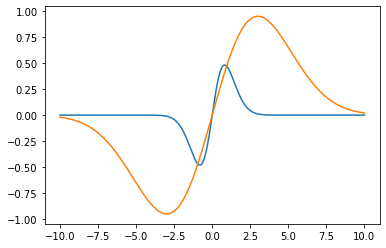

In [26]:
x = np.linspace(-10,10,1000)
y = (np.e**x - np.e**-x) / (np.e**x + np.e**-x) * (np.e**(-0.5 * x**2))
plt.plot(x, y)

s = 3
y = 0.5 * np.pi * x / s * np.exp(-x**2/(2*s**2))
plt.plot(x, y)

In [2]:
def rollificate(a):
    return np.roll(a, 1, 1)

rollificate_j = jit(rollificate)

In [3]:
rollificate_j(np.array([[1, 2], [3, 4]]))

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mNo implementation of function Function(<function roll at 0x743c3c1c1ea0>) found for signature:
 
 >>> roll(array(int64, 2d, C), Literal[int](1), Literal[int](1))
 
There are 2 candidate implementations:
[1m  - Of which 2 did not match due to:
  Overload in function 'np_roll': File: numba/np/arraymath.py: Line 2315.
    With argument(s): '(array(int64, 2d, C), int64, int64)':[0m
[1m   Rejected as the implementation raised a specific error:
     TypingError: [1mtoo many positional arguments[0m[0m
  raised from /home/erik/.local/lib/python3.10/site-packages/numba/core/typing/templates.py:783
[0m
[0m[1mDuring: resolving callee type: Function(<function roll at 0x743c3c1c1ea0>)[0m
[0m[1mDuring: typing of call at /tmp/ipykernel_6051/199662553.py (2)
[0m
[1m
File "../../../../../../../../tmp/ipykernel_6051/199662553.py", line 2:[0m
[1m<source missing, REPL/exec in use?>[0m


In [4]:
import torch

def vec_to_complex(v):
    return 1j * v[..., 1] + v[..., 0]

def complex_to_vec(v):
    return torch.stack((torch.real(v), torch.imag(v)), -1)

In [5]:
pos = torch.randn((10, 13, 2))
assert torch.allclose(complex_to_vec(vec_to_complex(pos)), pos)

In [6]:
pos.dtype

torch.float32

In [3]:
from metamaterial_envs.env.crawler_torch import calculate_vec, vec_angle, complex_mult
from metamaterial_envs.env.crawler_torch_complex import calculate

pos = torch.randn((10, 13, 2))
assert torch.allclose(torch.angle(vec_to_complex(pos)), vec_angle(pos))

a = torch.randn((10, 13, 2))
b = torch.randn((10, 13, 2))
assert torch.allclose(complex_to_vec(vec_to_complex(a) * vec_to_complex(b)),complex_mult(a,b))

pos = torch.randn((10, 13, 2))
vel = torch.randn((10, 13, 2))
teq = torch.pi

vec_ans = calculate_vec(pos, vel, teq)
complex_ans = calculate(vec_to_complex(pos), vec_to_complex(vel), teq)

for i, dtype in enumerate(['vec', 'vec', 'tens', 'vec', 'tens', 'tens', 'tens', 'tens', 'tens', 'tens', 'tens', 'vec', 'vec', 'vec']):
    if dtype == 'vec':
        if not torch.allclose(complex_to_vec(complex_ans[i]), vec_ans[i], atol=1e-6):
            print('complex ans:', complex_to_vec(complex_ans[i]))
            print('vec ans:', vec_ans[i])
            mask = torch.logical_not(torch.isclose(complex_to_vec(complex_ans[i]), vec_ans[i]))
            print('differences:', complex_to_vec(complex_ans[i])[mask], vec_ans[i][mask])
            raise AssertionError(f'failed assert {i}')
    elif dtype == 'tens':
        if not torch.allclose(complex_ans[i], vec_ans[i], atol=1e-6):
            print('complex ans:', complex_ans[i])
            print('vec ans:', vec_ans[i])
            mask = torch.logical_not(torch.isclose(complex_ans[i], vec_ans[i]))
            print('differences:', complex_ans[i][mask], vec_ans[i][mask])
            raise AssertionError(f'failed assert {i}')

/home/erik/.local/lib/python3.10/site-packages/torchrl/data/replay_buffers/samplers.py:34: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


pygame 2.6.1 (SDL 2.28.4, Python 3.10.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [8]:
from metamaterial_envs.env.crawler_torch import edge_force_vec
from metamaterial_envs.env.crawler_torch_complex import edge_force

pos = torch.randn((10, 13, 2))
vel = torch.randn((10, 13, 2))
r = torch.randn((10, 13, 2))
dv = torch.randn((10, 13, 2))
edge_stiffness, edge_damping = 1e3, 5

assert torch.allclose(
    edge_force_vec(pos, vel, edge_stiffness, edge_damping, r, dv),
    complex_to_vec(edge_force(vec_to_complex(pos), vec_to_complex(vel), edge_stiffness, edge_damping, vec_to_complex(r), vec_to_complex(dv))),
    atol=1e-4)